In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Load 06/2025 Yellow Taxi sample data
df_sample = pl.read_parquet("../dataset/Trip_Record/yellow/yellow_tripdata_2025-06.parquet")

print(f"Dataset Shape: {df_sample.shape}")
print(df_sample.describe())

Dataset Shape: (4322960, 20)
shape: (9, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ VendorID  ┆ tpep_pick ┆ tpep_drop ┆ … ┆ total_amo ┆ congestio ┆ Airport_f ┆ cbd_cong │
│ ---       ┆ ---       ┆ up_dateti ┆ off_datet ┆   ┆ unt       ┆ n_surchar ┆ ee        ┆ estion_f │
│ str       ┆ f64       ┆ me        ┆ ime       ┆   ┆ ---       ┆ ge        ┆ ---       ┆ ee       │
│           ┆           ┆ ---       ┆ ---       ┆   ┆ f64       ┆ ---       ┆ f64       ┆ ---      │
│           ┆           ┆ str       ┆ str       ┆   ┆           ┆ f64       ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 4.32296e6 ┆ 4322960   ┆ 4322960   ┆ … ┆ 4.32296e6 ┆ 3.110014e ┆ 3.110014e ┆ 4.32296e │
│           ┆           ┆           ┆           ┆   ┆           ┆ 6         ┆ 6         ┆ 6        │
│ null_coun ┆ 0.0       ┆ 0         ┆ 0        

In [3]:
# Check for missing values (Nulls)
null_summary = df_sample.null_count()
print("Null values per column:")
print(null_summary)

Null values per column:
shape: (1, 20)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ VendorID ┆ tpep_pick ┆ tpep_drop ┆ passenger ┆ … ┆ total_amo ┆ congestio ┆ Airport_f ┆ cbd_conge │
│ ---      ┆ up_dateti ┆ off_datet ┆ _count    ┆   ┆ unt       ┆ n_surchar ┆ ee        ┆ stion_fee │
│ u32      ┆ me        ┆ ime       ┆ ---       ┆   ┆ ---       ┆ ge        ┆ ---       ┆ ---       │
│          ┆ ---       ┆ ---       ┆ u32       ┆   ┆ u32       ┆ ---       ┆ u32       ┆ u32       │
│          ┆ u32       ┆ u32       ┆           ┆   ┆           ┆ u32       ┆           ┆           │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0        ┆ 0         ┆ 0         ┆ 1212946   ┆ … ┆ 0         ┆ 1212946   ┆ 1212946   ┆ 0         │
└──────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


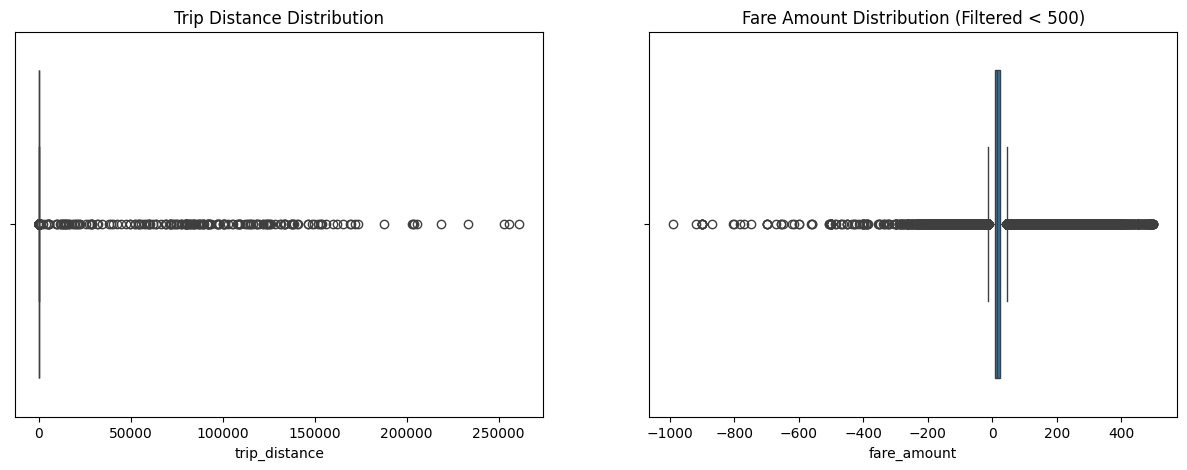

In [4]:
# Visualize distributions of distance and fare to identify outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Trip Distance Boxplot
sns.boxplot(data=df_sample.select("trip_distance").to_pandas(), x="trip_distance", ax=axes[0])
axes[0].set_title("Trip Distance Distribution")

# Fare Amount Boxplot (Filtered < 500 to see distribution clearly)
sns.boxplot(data=df_sample.filter(pl.col("fare_amount") < 500).select("fare_amount").to_pandas(), x="fare_amount", ax=axes[1])
axes[1].set_title("Fare Amount Distribution (Filtered < 500)")

plt.show()

Minimum Duration: -51.68333333333333 mins
Maximum Duration: 8596.1 mins


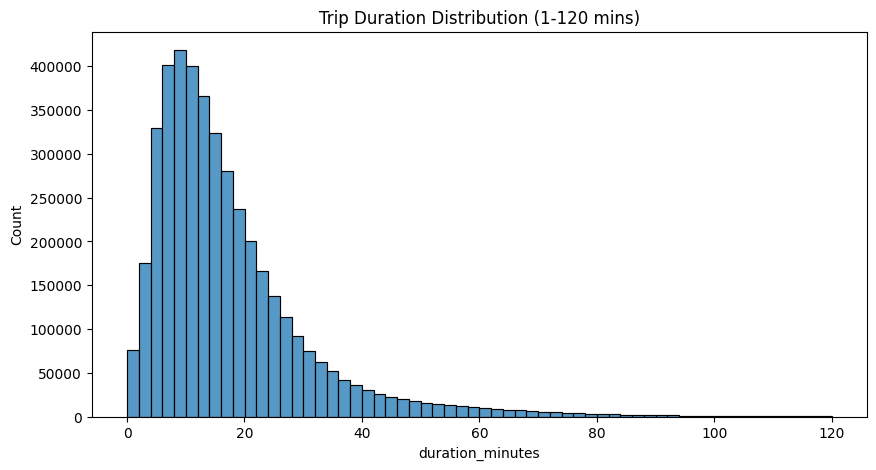

In [5]:
# Calculate trip duration in minutes and check for anomalies
df_sample = df_sample.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_seconds() / 60).alias("duration_minutes")
])

print(f"Minimum Duration: {df_sample['duration_minutes'].min()} mins")
print(f"Maximum Duration: {df_sample['duration_minutes'].max()} mins")

# Filter out trips with non-positive or extreme durations for visualization
plt.figure(figsize=(10, 5))
sns.histplot(df_sample.filter((pl.col("duration_minutes") > 0) & (pl.col("duration_minutes") < 120)).select("duration_minutes").to_pandas(), x="duration_minutes", bins=60)
plt.title("Trip Duration Distribution (1-120 mins)")
plt.show()

In [6]:
# Analyze passenger counts
passenger_counts = df_sample["passenger_count"].value_counts().sort("passenger_count")
print("Passenger Count Distribution:")
print(passenger_counts)

Passenger Count Distribution:
shape: (11, 2)
┌─────────────────┬─────────┐
│ passenger_count ┆ count   │
│ ---             ┆ ---     │
│ i64             ┆ u32     │
╞═════════════════╪═════════╡
│ null            ┆ 1212946 │
│ 0               ┆ 22791   │
│ 1               ┆ 2458387 │
│ 2               ┆ 431930  │
│ 3               ┆ 104573  │
│ …               ┆ …       │
│ 5               ┆ 14992   │
│ 6               ┆ 8651    │
│ 7               ┆ 2       │
│ 8               ┆ 6       │
│ 9               ┆ 3       │
└─────────────────┴─────────┘


C:\Users\tanba\AppData\Local\Temp\ipykernel_24524\1297767336.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("trip_count"))


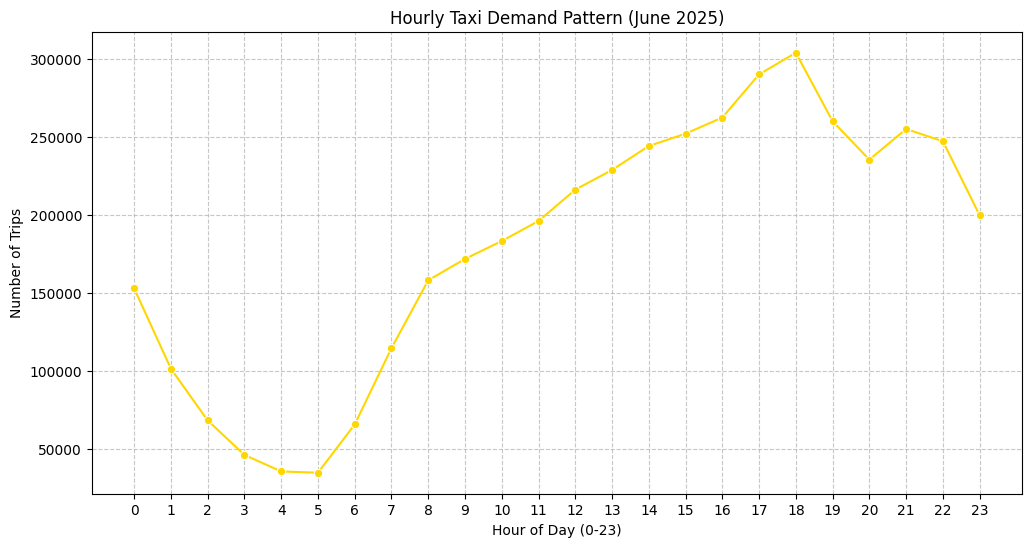

In [7]:
# Aggregate and visualize hourly demand patterns
hourly_demand = (
    df_sample
    .with_columns(pl.col("tpep_pickup_datetime").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.count().alias("trip_count"))
    .sort("hour")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_demand.to_pandas(), x="hour", y="trip_count", marker='o', color='gold')
plt.title("Hourly Taxi Demand Pattern (June 2025)")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()